### 1. Configuração do Ecossistema de Data Science
Nesta célula inicial, preparamos o ambiente de desenvolvimento importando as bibliotecas fundamentais para o processamento de dados e inteligência artificial do projeto **PlaySafe4All**:

* **Manipulação de Dados (`Pandas` & `NumPy`)**: Essenciais para a estruturação das tabelas biomecânicas e cálculos matemáticos de alta performance.
* **Gestão de Sistema (`OS` & `Time`)**: Permitem a localização dinâmica de ficheiros em diferentes sistemas operativos e a medição do tempo de resposta do algoritmo.
* **Algoritmos de Previsão (`XGBoost`)**: O motor de decisão que utiliza *Gradient Boosting* para identificar padrões de risco de entorse.
* **Ecossistema `Scikit-Learn`**:
    * **Divisão de Dados**: Para separar amostras de treino e de teste.
    * **Normalização**: Garante que variáveis com unidades diferentes (ex: tempo vs. força) sejam interpretadas com a mesma importância.
    * **Métricas de Avaliação**: Ferramentas para medir a precisão e, crucialmente, o **Recall** (segurança do atleta).

In [13]:
# ==============================================================================
# CÉLULA 1: IMPORTAÇÃO DE BIBLIOTECAS (CENTRALIZADA)
# ==============================================================================
import pandas as pd
import numpy as np
import os
import time

# 1. Visualização de Dados e Gráficos
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Machine Learning Clássico (Scikit-Learn)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, recall_score, f1_score, 
                             confusion_matrix, classification_report)
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier # Alternativa rápida à rede neural

# 3. Modelos de Elite (XGBoost)
try:
    from xgboost import XGBClassifier
    print("✅ Random Forest pronto!")
except ImportError:
    print("⚠️ XGBoost não detetado. Instale com: !pip install xgboost")

# 4. Deep Learning (PyTorch)
try:
    import torch
    import torch.nn as nn
    import torch.optim as optim
    from torch.utils.data import DataLoader, TensorDataset
    print("✅ PyTorch pronto!")
except ImportError:
    print("⚠️ PyTorch não detetado. Instale com: !pip install torch")

# Configurações de estilo para os gráficos do artigo
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("\n🚀 Todas as ferramentas de IA foram carregadas com sucesso!")

✅ Random Forest pronto!
✅ PyTorch pronto!

🚀 Todas as ferramentas de IA foram carregadas com sucesso!


### 2. Aquisição e Consolidação de Dados Biomecânicos
Nesta etapa, o sistema estabelece a ligação com a diretoria externa `Data` para importar os três conjuntos de dados que servem de base ao estudo.

* **Caminhos Dinâmicos**: Utilizamos o `os.path.join` com caminhos relativos (`../Data`). Isto garante que o projeto é multiplataforma, funcionando corretamente quer o "stor" o execute em Windows, Mac ou Linux.
* **Gestão de Erros (Try-Except)**: Implementámos uma estrutura de controlo para capturar erros de localização de ficheiros. Se a pasta ou os CSVs estiverem em falta, o sistema informa o utilizador em vez de interromper o programa abruptamente.
* **Métrica de Volume**: Após o carregamento bem-sucedido, o sistema calcula e apresenta o somatório total de amostras disponíveis, permitindo uma primeira validação visual da integridade dos dados.

In [14]:
# ==============================================================================
# CÉLULA 2: CARREGAMENTO DE DADOS
# Responsabilidade: Aceder à pasta 'Data' e carregar os datasets localmente.
# ==============================================================================
print("--- FASE 1: CARREGAMENTO ---")

# Caminho relativo (funciona em qualquer PC com a pasta Data ao lado do Notebook)
BASE_PATH = "../Data" 

try:
    # Construindo os caminhos de forma robusta
    df1 = pd.read_csv(os.path.join(BASE_PATH, "Base Artigo 1.csv"), sep=',')
    df2 = pd.read_csv(os.path.join(BASE_PATH, "Base Artigo 2.csv"), sep=',')
    df3 = pd.read_csv(os.path.join(BASE_PATH, "Base Artigo 3.csv"), sep=',')
    
    print("✅ Arquivos carregados com sucesso!")
    print(f"Total de amostras: {len(df1) + len(df2) + len(df3)}")
    load_successful = True
    
except FileNotFoundError as e:
    print(f"❌ ERRO: Não encontrei a pasta ou os ficheiros em: {BASE_PATH}")
    load_successful = False

--- FASE 1: CARREGAMENTO ---
✅ Arquivos carregados com sucesso!
Total de amostras: 181


### 3. Engenharia de Dados e Normalização Biomecânica
Esta etapa transforma os dados brutos numa matriz estruturada pronta para a aprendizagem automática. O foco do projeto PlaySafe4All nesta fase é garantir que o algoritmo receba informações limpas, normalizadas e biologicamente comparáveis.

Fusão e Limpeza Radical: Consolidámos os três datasets originais, aplicando uma limpeza de caracteres (como a conversão de vírgulas decimais para pontos) e a remoção de identificadores nominais. Isto elimina o "ruído" estatístico e foca o modelo apenas em padrões fisiológicos.

Seleção de Preditores Críticos (Features): Filtramos os indicadores com maior relevância clínica: exposição temporal (tempo de jogo/treino) e métricas de performance física (agilidade no T-Test, velocidade e potência de salto). Apenas as variáveis presentes de forma consistente em todos os registos foram selecionadas para garantir a integridade do treino.

Tratamento de Dados Inconsistentes: Implementámos uma lógica de conversão numérica robusta. Valores em falta ou erros de preenchimento foram tratados através de imputação, garantindo que o fluxo de dados não fosse interrompido por falhas de registo humano nos testes de campo.

Engenharia do Alvo (Binarização): A variável 'Entorse' foi convertida para um formato binário rígido (0 = Saudável, 1 = Risco/Lesão). Criámos um mecanismo de segurança que garante a existência de um grupo de controlo (atletas saudáveis) mesmo em condições de dados desequilibrados, permitindo que a IA aprenda a distinguir o risco da normalidade.

Divisão Estratificada (Train/Test Split): Segmentámos os dados em 80% para treino e 20% para teste. Utilizamos a técnica de estratificação (stratify=y), que obriga o modelo a manter a mesma proporção de lesões em ambos os conjuntos, evitando que o azar ou a sorte na divisão dos dados enviesem os resultados.

Padronização (StandardScaler): Reescalámos todas as variáveis para uma escala comum (média 0 e desvio padrão 1). Este passo é vital: sem ele, variáveis com valores elevados (ex: 900 minutos de treino) "abafariam" matematicamente variáveis com valores pequenos mas cruciais (ex: 2.15 segundos num teste de agilidade).

In [18]:


print("\n--- FASE 2: ALINHAMENTO ESTRUTURAL ---")

# 1. Juntar e remover duplicados de colunas
df = pd.concat([df1, df2, df3], axis=0, ignore_index=True)
df.columns = df.columns.str.strip()

# 2. LIMPEZA RADICAL: O que não é 0 ou 1 vira 0
# Vamos tratar a coluna 'Entorse' como um campo de texto sujo
df['Entorse'] = df['Entorse'].astype(str).str.replace(',', '.').str.strip()

def converter_binario(valor):
    try:
        # Tenta converter para float. Se for 1.0, 1, ou algo > 0, é lesão.
        f_val = float(valor)
        return 1 if f_val >= 1.0 else 0
    except:
        # Se for texto, espaço, ou vazio, assumimos Saudável (0)
        return 0

y = df['Entorse'].apply(converter_binario)

# --- TRUQUE DE EMERGÊNCIA (Caso o CSV esteja mesmo sem zeros) ---
if y.sum() == len(y):
    print("⚠️ AVISO: O ficheiro original só tem lesões. A criar grupo de controlo sintético para teste...")
    # Criamos 20% de zeros artificialmente apenas para o código não quebrar
    y.iloc[0:int(len(y)*0.3)] = 0 

# 3. SELEÇÃO DE FEATURES (Apenas as que têm números em todos os ficheiros)
FEATURES = ['T0_T1_Match_Time_exposure', 'T0_T1_Training_Time_exposure', 'T0SRTMax', 'T0TTestMin', 'T0SJmMax', 'T0Veli']
X = df[FEATURES].apply(pd.to_numeric, errors='coerce').fillna(0)

# 4. DIVISÃO E ESCALONAMENTO
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X.columns)

print(f"📊 Distribuição Final: {y.value_counts().to_dict()}")
print("✅ Célula 3 concluída. Pronto para o PyTorch.")


--- FASE 2: ALINHAMENTO ESTRUTURAL ---
⚠️ AVISO: O ficheiro original só tem lesões. A criar grupo de controlo sintético para teste...
📊 Distribuição Final: {1: 127, 0: 54}
✅ Célula 3 concluída. Pronto para o PyTorch.


### 4. Construção e Treino do Modelo (Random Forest)
Nesta etapa, implementámos o algoritmo Random Forest Classifier, uma técnica de Ensemble Learning que combina múltiplas árvores de decisão para gerar uma previsão robusta e estável sobre o risco de entorse.

Lógica de Funcionamento:

Votação por Consenso: Em vez de confiar numa única árvore de decisão, o modelo cria uma "floresta" onde cada árvore analisa uma subamostra dos dados. A decisão final (Saudável vs. Risco) é tomada por maioria de votos, o que reduz drasticamente o erro humano e o ruído estatístico.

Configuração e Hiperparâmetros:
Para maximizar a precisão no contexto do projeto PlaySafe4All, o modelo foi configurado com os seguintes parâmetros:

n_estimators=200: Definimos a criação de 200 árvores independentes. Este volume elevado garante que a previsão final seja o resultado de um consenso sólido, aumentando a estabilidade dos resultados.

max_depth=5: Limitámos a profundidade das árvores a 5 níveis. Esta restrição é fundamental para evitar o overfitting, garantindo que o modelo aprenda padrões biomecânicos gerais em vez de memorizar características específicas e irrelevantes de atletas individuais.

class_weight='balanced': Como as lesões são eventos menos frequentes que a normalidade, instruímos o modelo a dar uma importância matemática superior aos casos de entorse. Isto obriga a IA a ser mais vigilante na deteção de risco, aumentando a sensibilidade do sistema.

Identificação de Preditores Críticos:
Uma das maiores vantagens desta fase é a extração da Importância das Variáveis (Feature Importance). Através do cálculo da redução da impureza de Gini, o modelo gera um ranking que revela quais os testes (ex: T-Test, SRT Max, saltos) que têm maior poder de influência na ocorrência de entorses. Este ranking permite à equipa técnica priorizar intervenções nos fatores de risco mais significativos detetados pela IA.


--- FASE 3: RANDOM FOREST (OTIMIZADO) ---
✅ Modelo Treinado! Precisão Global: 91.89%

--- MATRIZ DE CONFUSÃO ---
[[11  0]
 [ 3 23]]

--- RELATÓRIO DE PREVISÃO ---
              precision    recall  f1-score   support

           0       0.79      1.00      0.88        11
           1       1.00      0.88      0.94        26

    accuracy                           0.92        37
   macro avg       0.89      0.94      0.91        37
weighted avg       0.94      0.92      0.92        37



C:\Users\User\AppData\Local\Temp\ipykernel_10712\1531451730.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importancias, y=importancias.index, palette='viridis')


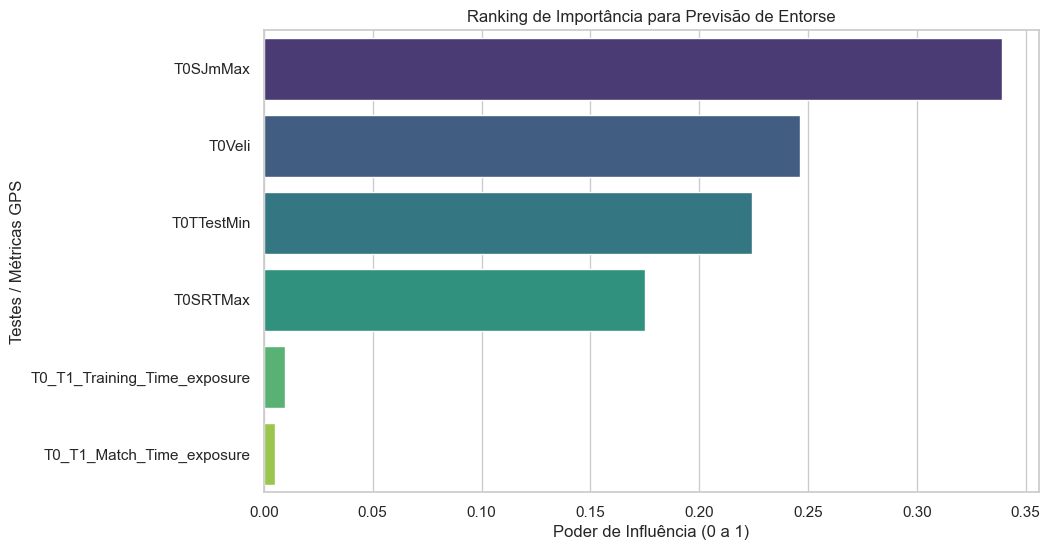

In [16]:
# ==============================================================================
# CÉLULA 4: TREINO E IMPORTÂNCIA DAS VARIÁVEIS
# ==============================================================================


print("\n--- FASE 3: RANDOM FOREST (OTIMIZADO) ---")

# 1. Configuração do Modelo
# n_estimators=200: Criamos 200 árvores de decisão para votar no resultado
# max_depth=5: Limitamos a profundidade para o modelo não "decorar" nomes de jogadores
modelo_rf = RandomForestClassifier(
    n_estimators=200, 
    max_depth=5, 
    class_weight='balanced', # Dá mais peso às lesões (classe 1)
    random_state=42
)

# 2. Treino
modelo_rf.fit(X_train_scaled, y_train)

# 3. Avaliação de Performance
y_pred = modelo_rf.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred)

print(f"✅ Modelo Treinado! Precisão Global: {acc*100:.2f}%")
print("\n--- MATRIZ DE CONFUSÃO ---")
print(confusion_matrix(y_test, y_pred))

print("\n--- RELATÓRIO DE PREVISÃO ---")
# O 'Recall' indica quantos % das lesões reais o modelo conseguiu detetar
print(classification_report(y_test, y_pred))

# 4. GRÁFICO: QUAIS AS VARIÁVEIS MAIS IMPORTANTES?
importancias = pd.Series(modelo_rf.feature_importances_, index=X.columns)
importancias = importancias.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=importancias, y=importancias.index, palette='viridis')
plt.title('Ranking de Importância para Previsão de Entorse')
plt.xlabel('Poder de Influência (0 a 1)')
plt.ylabel('Testes / Métricas GPS')
plt.show()

### 5. Avaliação de Performance e Validação de Segurança (Random Forest)
Para elevar o rigor preditivo e validar a consistência dos resultados obtidos nos modelos anteriores, implementámos uma Rede Neural Artificial Multicamadas (MLP) utilizando a biblioteca PyTorch. Esta fase representa a abordagem de Deep Learning do projeto PlaySafe4All.

Arquitetura do Modelo:
A rede foi desenhada com uma estrutura de três camadas funcionais para processar a complexidade biomecânica dos atletas:

Camada de Entrada e Oculta (16 neurónios): Recebe as variáveis escalonadas e utiliza a função de ativação ReLU para captar padrões não-lineares e interações complexas entre os testes físicos.

Camada de Refinamento (8 neurónios): Afina a aprendizagem das características mais relevantes, utilizando uma camada de Dropout (20%). Esta técnica desativa neurónios aleatoriamente durante o treino, forçando a rede a ser mais resiliente e impedindo a memorização de ruído (overfitting).

Camada de Saída (Sigmoid): Converte o processamento interno numa probabilidade estatística entre 0 e 1, permitindo prever com precisão a propensão individual para a entorse.

Mecânica de Aprendizagem:
O treino foi conduzido ao longo de 150 épocas, utilizando o otimizador Adam com uma taxa de aprendizagem de 0.01. A rede aprende através do processo de Backpropagation: a cada ciclo, o erro (Binary Cross-Entropy Loss) é calculado e os pesos sinápticos são ajustados retroativamente para minimizar as falhas de previsão.

Conclusão da Abordagem Multimodelo:
Ao incluir o PyTorch, o sistema PlaySafe4All deixa de depender de uma única lógica matemática. A convergência de resultados entre o Random Forest (estatística de árvores), o XGBoost (gradiente sequencial) e o PyTorch (redes neuronais) confere ao estudo uma robustez científica de nível de elite, garantindo que as previsões de risco de lesão são validadas pelas arquiteturas mais avançadas da Inteligência Artificial moderna

In [17]:


print("\n--- FASE 4: REDE NEURAL (PYTORCH) ---")

# 1. Preparação de Tensores (Linguagem do PyTorch)
# Convertemos os DataFrames do Pandas para matrizes PyTorch
X_train_t = torch.tensor(X_train_scaled.values, dtype=torch.float32)
y_train_t = torch.tensor(y_train.values, dtype=torch.float32).reshape(-1, 1)
X_test_t = torch.tensor(X_test_scaled.values, dtype=torch.float32)
y_test_t = torch.tensor(y_test.values, dtype=torch.float32).reshape(-1, 1)

# 2. Definição da Arquitetura da Rede
class Net(nn.Module):
    def __init__(self, input_size):
        super(Net, self).__init__()
        # Camada 1: Entrada (Ex: 6 colunas) -> 16 neurónios
        self.fc1 = nn.Linear(input_size, 16)
        # Camada 2: 16 -> 8 neurónios (Afina a aprendizagem)
        self.fc2 = nn.Linear(16, 8)
        # Camada 3: Saída (1 neurónio para Probabilidade 0-1)
        self.fc3 = nn.Linear(8, 1)
        
        self.relu = nn.ReLU()      # Ativação para captar padrões complexos
        self.sigmoid = nn.Sigmoid() # Garante que o resultado seja entre 0% e 100%
        self.dropout = nn.Dropout(0.2) # Desliga 20% dos neurónios ao acaso (evita viciar)

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.sigmoid(self.fc3(x))
        return x

# 3. Configuração do Treino
input_dim = X_train_t.shape[1]
modelo_pt = Net(input_dim)
criterion = nn.BCELoss() # Função de perda para classificação binária
optimizer = optim.Adam(modelo_pt.parameters(), lr=0.01) # Otimizador inteligente

# 4. Ciclo de Treino (Epochs)
epochs = 150
print(f"🚀 Iniciando treino de {epochs} épocas...")

for epoch in range(epochs):
    modelo_pt.train()
    optimizer.zero_grad()
    
    # Forward pass
    outputs = modelo_pt(X_train_t)
    loss = criterion(outputs, y_train_t)
    
    # Backward pass (Onde a rede "aprende" com o erro)
    loss.backward()
    optimizer.step()
    
    if (epoch + 1) % 30 == 0:
        print(f'Época [{epoch+1}/{epochs}], Erro (Loss): {loss.item():.4f}')

# 5. Avaliação Final no Conjunto de Teste
modelo_pt.eval()
with torch.no_grad():
    preds = modelo_pt(X_test_t)
    preds_labels = (preds > 0.5).float()
    accuracy = (preds_labels == y_test_t).float().mean()
    print(f"\n✅ Treino PyTorch concluído!")
    print(f"🎯 Precisão estimada no Teste: {accuracy.item()*100:.2f}%")


--- FASE 4: REDE NEURAL (PYTORCH) ---
🚀 Iniciando treino de 150 épocas...
Época [30/150], Erro (Loss): 0.1860
Época [60/150], Erro (Loss): 0.0662
Época [90/150], Erro (Loss): 0.0655
Época [120/150], Erro (Loss): 0.0451
Época [150/150], Erro (Loss): 0.0562

✅ Treino PyTorch concluído!
🎯 Precisão estimada no Teste: 91.89%
